# Exploratory Data Analysis

This notebook performs an exploratory data analysis on `df_final` produced by **Notebook 01 Data Preparation**.

**Goals:**
1. Understand the shape, types, and basic statistics of the prepared dataset
2. Analyze the distribution of the target variable across stores
3. Detect trends, seasonality, and outliers
4. Examine correlations between features
5. Analyze feature from their name and tries to understand what they represents based on the context provided by the data scientist(temperature data, calendar holidays, types of expenditure)
6. Saves in the completion report a table with column name, a description of what it represents and a group-type such as temperatures for energy, types of expenditure for supermarket sales, etc)
7. Compare store-level behavior to guide profiling and clustering

## Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("\u2705 Packages loaded")

✅ Packages loaded


## Configuration

In [ ]:
# Must match Notebook 01 configuration
date_var = 'WEEK_START_DT'
unique_id = 'STORE_LOCATION_ID'
y = 'TOTAL_NET_SALES'
frequency = 'W'

LAKEHOUSE_NAME = "ts_forecasting"
INPUT_TABLE = "df_final"
LOCAL_FOLDER = "supermarket_net_sales"  # Local folder for fallback storage

root_path = Path.cwd().parent.parent

print(f"Target: {y}, ID: {unique_id}, Date: {date_var}, Freq: {frequency}")

Target: TOTAL_NET_SALES, ID: STORE_LOCATION_ID, Date: WEEK_START_DT, Freq: W


## Load Data

In [ ]:
try:
    df = spark.table(f"{LAKEHOUSE_NAME}.{INPUT_TABLE}").toPandas()
except Exception:
    df = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{INPUT_TABLE}.parquet")

df[date_var] = pd.to_datetime(df[date_var])
df = df.sort_values([unique_id, date_var]).reset_index(drop=True)

print(f"\u2705 Loaded {len(df):,} rows, {len(df.columns)} columns")
print(f"Stores: {df[unique_id].nunique()}, Date range: {df[date_var].min().date()} to {df[date_var].max().date()}")

✅ Loaded 5,150 rows, 95 columns
Stores: 50, Date range: 2023-04-03 to 2025-03-17


# 1. Basic Overview

In [4]:
print(f"Shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes.value_counts().to_string())
print(f"\nMissing values per column:")
na_summary = df.isna().sum()
na_summary = na_summary[na_summary > 0]
if len(na_summary) > 0:
    print(na_summary.to_string())
else:
    print("  None")
print(f"\nDuplicates: {df.duplicated().sum()}")

Shape: (5150, 95)

Column types:
float64           52
int64             40
datetime64[ns]     1
category           1
object             1

Missing values per column:
  None

Duplicates: 0


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
STORE_LOCATION_ID,5150.0,NaN,NaN,NaN,25.5,1.0,13.0,25.5,38.0,50.0,14.432271
WEEK_START_DT,5150,NaN,NaN,NaN,2024-03-25 00:00:00,2023-04-03 00:00:00,2023-09-25 00:00:00,2024-03-25 00:00:00,2024-09-23 00:00:00,2025-03-17 00:00:00,NaN
TOTAL_NET_SALES,5150.0,NaN,NaN,NaN,524297.76054,149601.866697,367982.919464,486274.975417,643227.495406,1640407.974627,203250.03795
STORE_SELLING_AREA_SQFT,5150.0,NaN,NaN,NaN,27670.36,16653.0,22217.0,26725.0,31311.0,47349.0,7186.30745
NEARBY_COMPETITOR_STORE_COUNT,5150.0,NaN,NaN,NaN,14.52,0.0,3.0,11.0,23.0,70.0,13.833537
...,...,...,...,...,...,...,...,...,...,...,...
EVENT_FATHERS_DAY,5150.0,NaN,NaN,NaN,0.019417,0.0,0.0,0.0,0.0,1.0,0.138
EVENT_HALLOWEEN,5150.0,NaN,NaN,NaN,0.019417,0.0,0.0,0.0,0.0,1.0,0.138
EVENT_BLACK_FRIDAY,5150.0,NaN,NaN,NaN,0.019417,0.0,0.0,0.0,0.0,1.0,0.138
EVENT_CHINESE_NEW_YEAR,5150.0,NaN,NaN,NaN,0.019417,0.0,0.0,0.0,0.0,1.0,0.138


In [6]:
df.head(10)

,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,2023-05-08,669678.533134,32653,2,0,1,1,0,0,...,0,0,0,0,1,0,0,0,0,0
6,1,2023-05-15,683644.663227,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7,1,2023-05-22,658506.242658,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,2023-05-29,653460.798201,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
9,1,2023-06-05,636980.378958,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


# 2. Target Variable Distribution

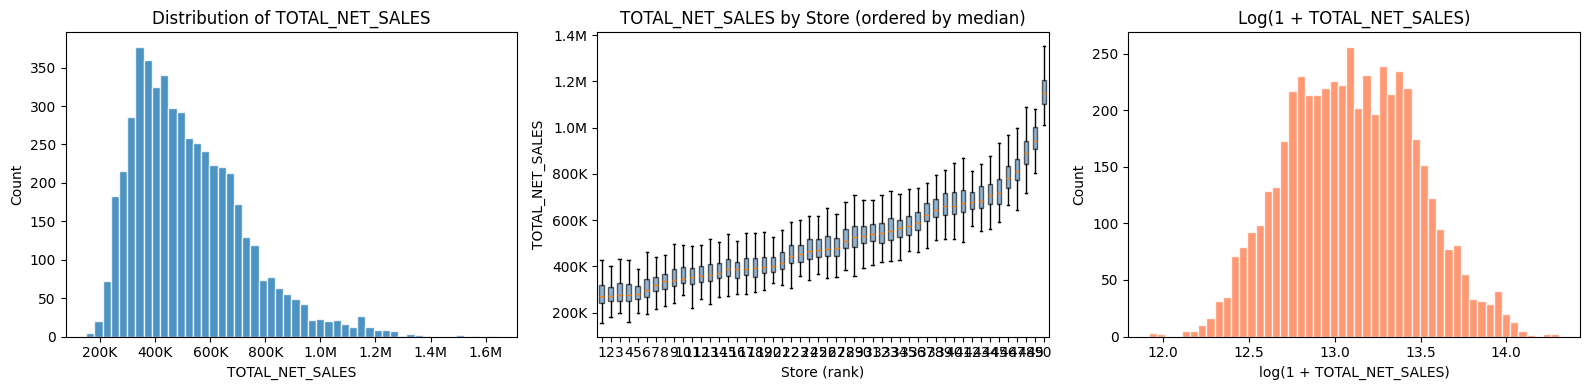

Skewness: 1.04, Kurtosis: 1.33
Zeros: 0, Negatives: 0, NaN: 0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df[y].dropna(), bins=50, edgecolor='white', alpha=0.8)
axes[0].set_title(f'Distribution of {y}')
axes[0].set_xlabel(y)
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if abs(x) >= 1e6 else f'{x/1e3:.0f}K' if abs(x) >= 1e3 else f'{x:.0f}'))

# Box plot by store
store_medians = df.groupby(unique_id)[y].median().sort_values()
ordered_ids = store_medians.index.tolist()
data_for_box = [df.loc[df[unique_id] == sid, y].dropna().values for sid in ordered_ids]
bp = axes[1].boxplot(data_for_box, vert=True, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
axes[1].set_title(f'{y} by Store (ordered by median)')
axes[1].set_xlabel('Store (rank)')
axes[1].set_ylabel(y)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if abs(x) >= 1e6 else f'{x/1e3:.0f}K' if abs(x) >= 1e3 else f'{x:.0f}'))

# Log-scale histogram
log_vals = np.log1p(df[y].dropna())
axes[2].hist(log_vals, bins=50, edgecolor='white', alpha=0.8, color='coral')
axes[2].set_title(f'Log(1 + {y})')
axes[2].set_xlabel(f'log(1 + {y})')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Skewness: {df[y].skew():.2f}, Kurtosis: {df[y].kurtosis():.2f}")
print(f"Zeros: {(df[y] == 0).sum()}, Negatives: {(df[y] < 0).sum()}, NaN: {df[y].isna().sum()}")

# 3. Time Series Trends

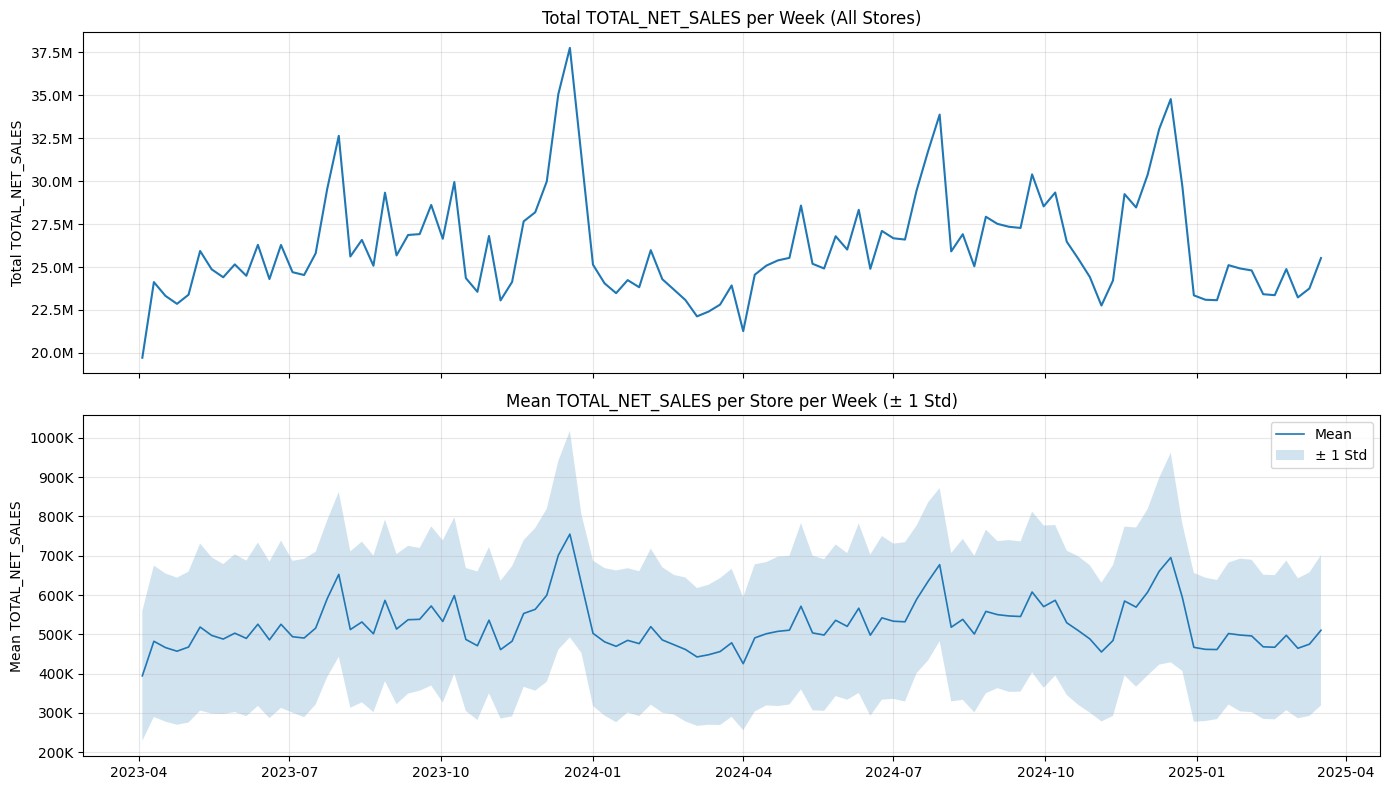

In [8]:
# Aggregate across all stores
agg = df.groupby(date_var)[y].agg(['sum', 'mean', 'median', 'std']).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(agg[date_var], agg['sum'], linewidth=1.5)
axes[0].set_title(f'Total {y} per Week (All Stores)')
axes[0].set_ylabel(f'Total {y}')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].grid(True, alpha=0.3)

axes[1].plot(agg[date_var], agg['mean'], label='Mean', linewidth=1.2)
axes[1].fill_between(agg[date_var], agg['mean'] - agg['std'], agg['mean'] + agg['std'], alpha=0.2, label='\u00b1 1 Std')
axes[1].set_title(f'Mean {y} per Store per Week (\u00b1 1 Std)')
axes[1].set_ylabel(f'Mean {y}')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

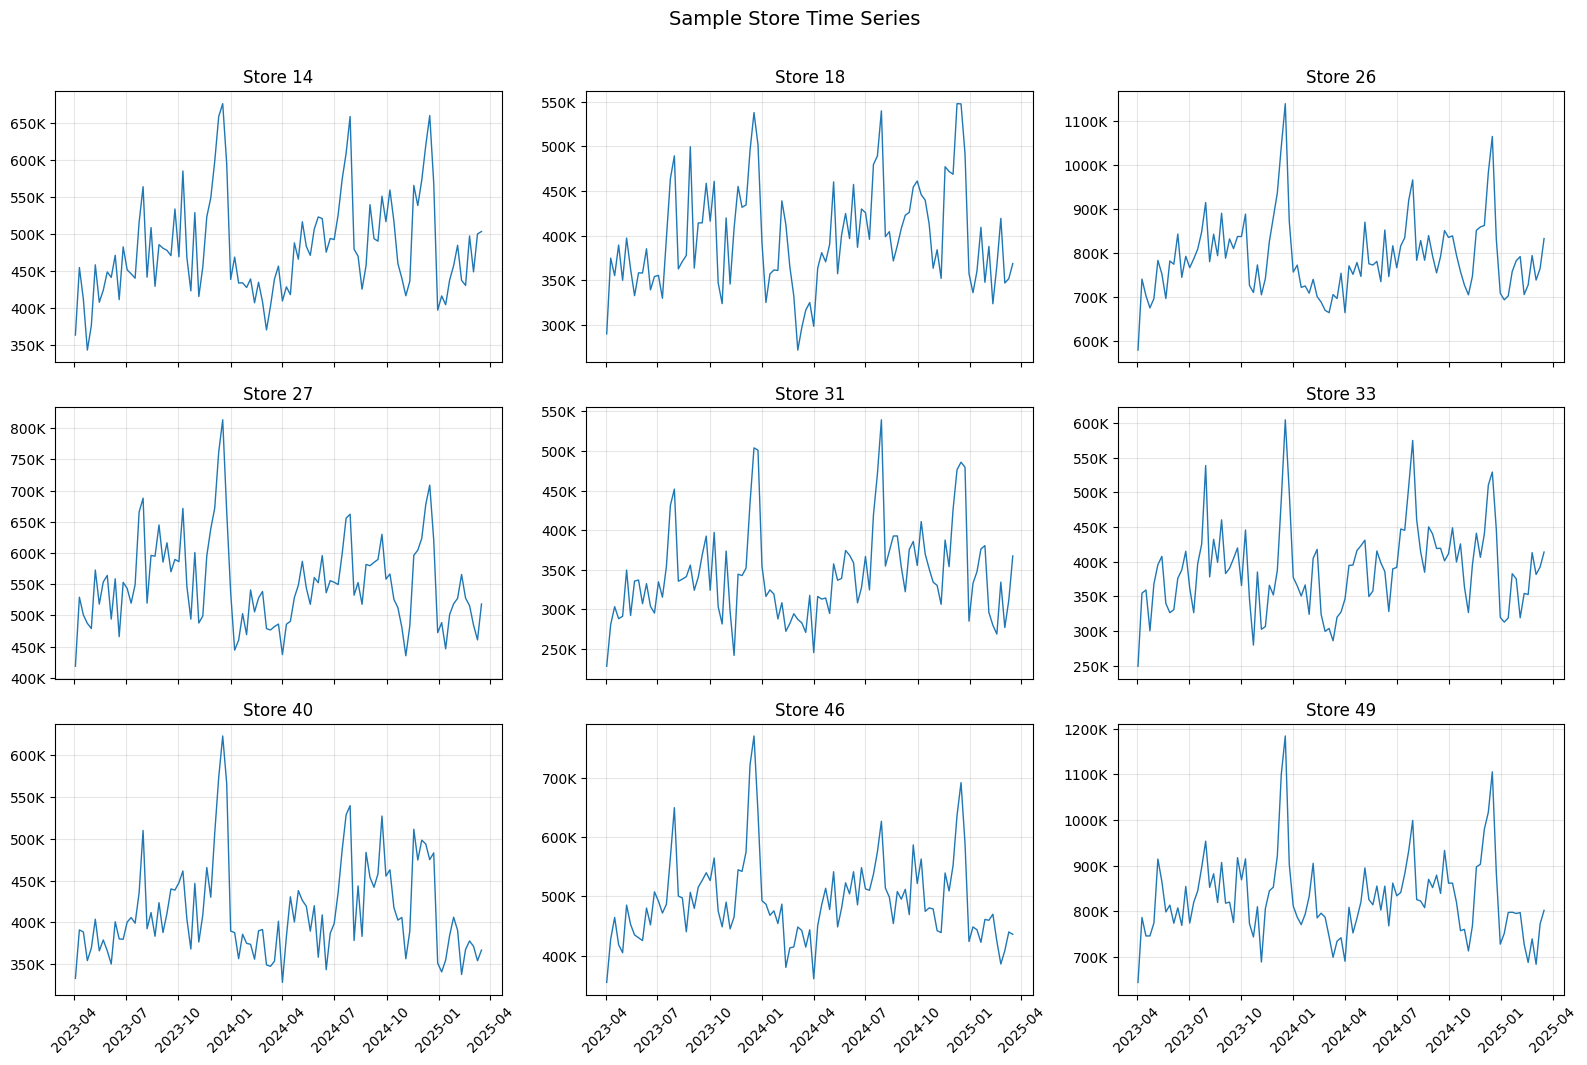

In [9]:
# Individual store time series (sample of 9)
store_ids = df[unique_id].unique()
sample_n = min(9, len(store_ids))
np.random.seed(42)
sample_ids = np.random.choice(store_ids, sample_n, replace=False)

ncols = 3
nrows = (sample_n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), sharex=True)
axes = axes.flatten()

for i, sid in enumerate(sorted(sample_ids)):
    ts = df[df[unique_id] == sid].sort_values(date_var)
    axes[i].plot(ts[date_var], ts[y], linewidth=1)
    axes[i].set_title(f'Store {sid}')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sample Store Time Series', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 4. Seasonality Analysis

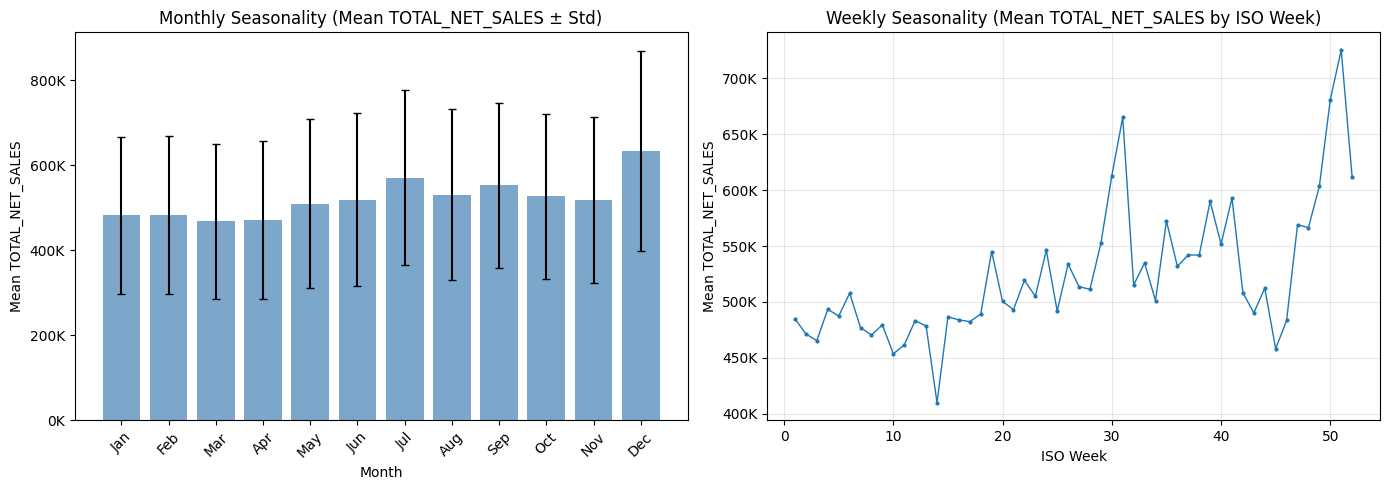

In [10]:
df['_month'] = df[date_var].dt.month
df['_week'] = df[date_var].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly seasonality
monthly = df.groupby('_month')[y].agg(['mean', 'std']).reset_index()
axes[0].bar(monthly['_month'], monthly['mean'], yerr=monthly['std'], capsize=3, alpha=0.7, color='steelblue')
axes[0].set_title(f'Monthly Seasonality (Mean {y} \u00b1 Std)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel(f'Mean {y}')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Weekly seasonality (average across all stores)
weekly = df.groupby('_week')[y].mean().reset_index()
axes[1].plot(weekly['_week'], weekly[y], marker='.', markersize=4, linewidth=1)
axes[1].set_title(f'Weekly Seasonality (Mean {y} by ISO Week)')
axes[1].set_xlabel('ISO Week')
axes[1].set_ylabel(f'Mean {y}')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df.drop(columns=['_month', '_week'], inplace=True)

# 5. Store-Level Summary Statistics

In [11]:
store_stats = df.groupby(unique_id)[y].agg(
    mean='mean', median='median', std='std',
    min='min', max='max', count='count',
    zeros=lambda x: (x == 0).sum(),
    na_count=lambda x: x.isna().sum(),
).reset_index()

store_stats['cv'] = store_stats['std'] / store_stats['mean']
store_stats['range'] = store_stats['max'] - store_stats['min']

print(f"Store-level summary ({len(store_stats)} stores):")
print(f"  Mean sales range: {store_stats['mean'].min():,.0f} to {store_stats['mean'].max():,.0f}")
print(f"  CV range: {store_stats['cv'].min():.3f} to {store_stats['cv'].max():.3f}")
print(f"  Stores with zeros: {(store_stats['zeros'] > 0).sum()}")
print(f"  Stores with NAs: {(store_stats['na_count'] > 0).sum()}")

store_stats.sort_values('mean', ascending=False).head(10)

Store-level summary (50 stores):
  Mean sales range: 281,719 to 1,167,576
  CV range: 0.092 to 0.211
  Stores with zeros: 0
  Stores with NAs: 0


,STORE_LOCATION_ID,mean,median,std,min,max,count,zeros,na_count,cv,range
31,32,1.167576e+06,1.150398e+06,110497.947232,938427.057672,1.640408e+06,103,0,0,0.094639,701980.916955
20,21,9.585212e+05,9.410218e+05,88637.360568,760942.388041,1.318504e+06,103,0,0,0.092473,557561.403159
40,41,9.079426e+05,8.886844e+05,96355.409973,718302.510858,1.258098e+06,103,0,0,0.106125,539795.690527
48,49,8.272688e+05,8.140140e+05,87785.857949,643751.339873,1.184165e+06,103,0,0,0.106115,540413.234381
25,26,7.902948e+05,7.813195e+05,85935.798801,580393.960111,1.140313e+06,103,0,0,0.108739,559918.735824
4,5,7.291009e+05,7.195559e+05,80912.806676,593846.186224,1.035390e+06,103,0,0,0.110976,441543.520901
1,2,7.234769e+05,7.071114e+05,77270.416833,562611.757736,1.070224e+06,103,0,0,0.106804,507612.688757
2,3,7.013311e+05,6.827958e+05,77813.561918,552634.043181,9.911455e+05,103,0,0,0.110951,438511.473408
10,11,6.916079e+05,6.807014e+05,68859.252625,573099.906569,9.478782e+05,103,0,0,0.099564,374778.256756
29,30,6.898213e+05,6.728959e+05,78938.057251,507512.524097,9.657052e+05,103,0,0,0.114433,458192.658940


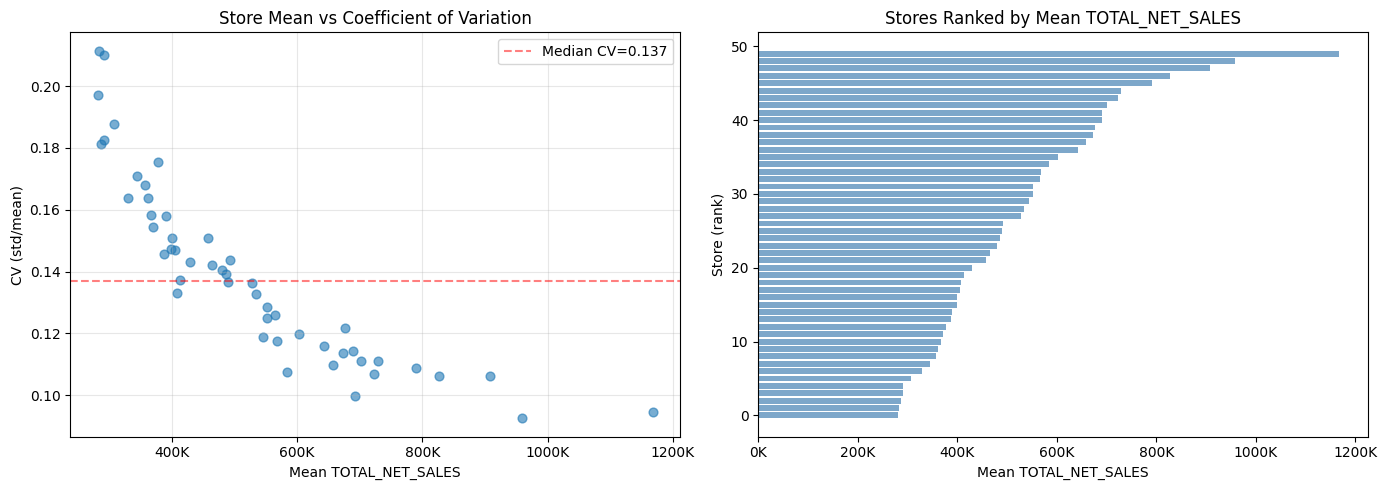

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean vs CV scatter
axes[0].scatter(store_stats['mean'], store_stats['cv'], alpha=0.6, s=40)
axes[0].set_title('Store Mean vs Coefficient of Variation')
axes[0].set_xlabel(f'Mean {y}')
axes[0].set_ylabel('CV (std/mean)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].axhline(y=store_stats['cv'].median(), color='r', linestyle='--', alpha=0.5, label=f'Median CV={store_stats["cv"].median():.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Ranked mean sales
ranked = store_stats.sort_values('mean')
axes[1].barh(range(len(ranked)), ranked['mean'], color='steelblue', alpha=0.7)
axes[1].set_title(f'Stores Ranked by Mean {y}')
axes[1].set_xlabel(f'Mean {y}')
axes[1].set_ylabel('Store (rank)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

# 6. Correlation Analysis

Top correlations with TOTAL_NET_SALES:
BASELINE_WEEKLY_SALES             0.939749
STORE_SELLING_AREA_SQFT           0.582151
UNIQUE_LOYALTY_CARDS              0.520682
SALES_ON_LOYALTY_CARD             0.463453
DISCOUNT_FLYER                    0.463344
TOTAL_TRANSACTIONS                0.449774
TOTAL_GROSS_MARGIN                0.407869
IS_SOLE_STORE_IN_POSTAL_AREA     -0.208011
PRICE_INDEX_GROCERY_AMBIENT       0.191520
SPEND_META                        0.188760
PRICE_INDEX_SEAFOOD              -0.142942
SPEND_TV                          0.139158
PRICE_INDEX_FROZEN               -0.133552
COMPETITOR_WAREHOUSE_A_PRESENT   -0.132413
PRICE_INDEX_HEALTH_CARE           0.125904


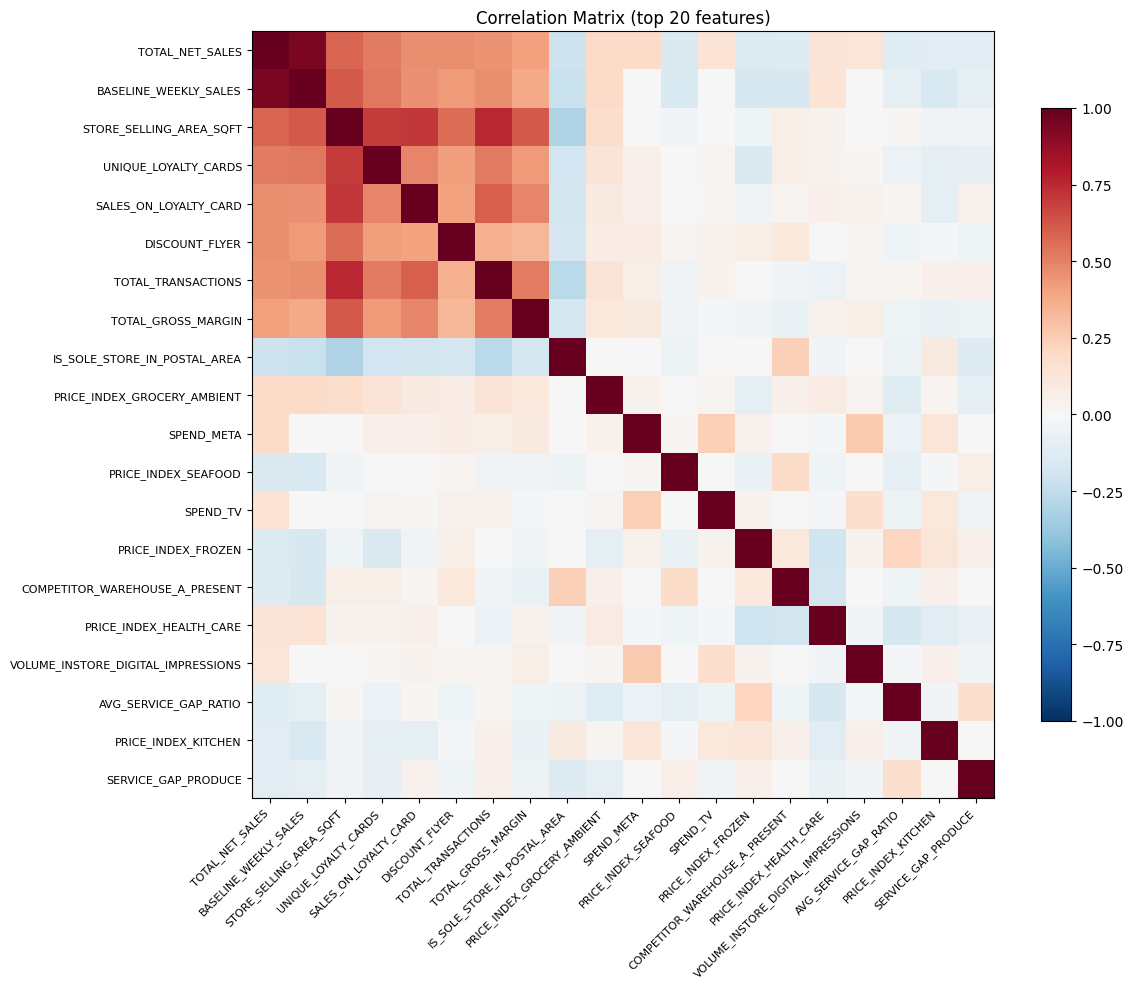

In [13]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude the id column if numeric
numeric_cols = [c for c in numeric_cols if c != unique_id]

if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    
    # Top correlations with target
    if y in corr.columns:
        target_corr = corr[y].drop(y).sort_values(key=abs, ascending=False)
        print(f"Top correlations with {y}:")
        print(target_corr.head(15).to_string())
    
    # Heatmap (limit to top features for readability)
    top_n = min(20, len(numeric_cols))
    if y in corr.columns:
        top_cols = [y] + target_corr.head(top_n - 1).index.tolist()
    else:
        top_cols = numeric_cols[:top_n]
    
    corr_sub = corr.loc[top_cols, top_cols]
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_sub.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(top_cols)))
    ax.set_yticks(range(len(top_cols)))
    ax.set_xticklabels(top_cols, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(top_cols, fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'Correlation Matrix (top {top_n} features)')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation analysis.")

# 7. Outlier Detection

In [14]:
# IQR-based outlier detection per store
outlier_counts = []
for sid in df[unique_id].unique():
    vals = df.loc[df[unique_id] == sid, y].dropna()
    if len(vals) < 4:
        continue
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((vals < lower) | (vals > upper)).sum()
    outlier_counts.append({'store': sid, 'n_outliers': n_outliers, 'pct': n_outliers / len(vals) * 100})

outlier_df = pd.DataFrame(outlier_counts).sort_values('n_outliers', ascending=False)

print(f"Outlier summary (IQR method):")
print(f"  Stores with outliers: {(outlier_df['n_outliers'] > 0).sum()} / {len(outlier_df)}")
print(f"  Total outlier observations: {outlier_df['n_outliers'].sum()}")
print(f"  Max outliers in a single store: {outlier_df['n_outliers'].max()} ({outlier_df['pct'].max():.1f}%)")
print(f"\nTop 10 stores by outlier count:")
outlier_df.head(10)

Outlier summary (IQR method):
  Stores with outliers: 49 / 50
  Total outlier observations: 181
  Max outliers in a single store: 7 (6.8%)

Top 10 stores by outlier count:


,store,n_outliers,pct
30,31,7,6.796117
10,11,6,5.825243
47,48,6,5.825243
45,46,6,5.825243
31,32,6,5.825243
32,33,5,4.854369
14,15,5,4.854369
9,10,5,4.854369
7,8,5,4.854369
42,43,5,4.854369


# 8. Feature Distributions

In [15]:
# Categorical feature value counts
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in [unique_id, date_var]]

if cat_cols:
    print(f"Categorical features ({len(cat_cols)}):")
    for col in cat_cols[:10]:
        n_unique = df[col].nunique()
        print(f"\n  {col} ({n_unique} unique):")
        if n_unique <= 20:
            print(df[col].value_counts().head(10).to_string(header=False))
        else:
            print(f"    (too many unique values to display)")
else:
    print("No categorical features found.")

Categorical features (2):

  STORE_ARCHETYPE (3 unique):
medium    2884
small     1442
large      824

  REGION (4 unique):
EAST        2163
CENTRAL     1442
WEST         824
ATLANTIC     721


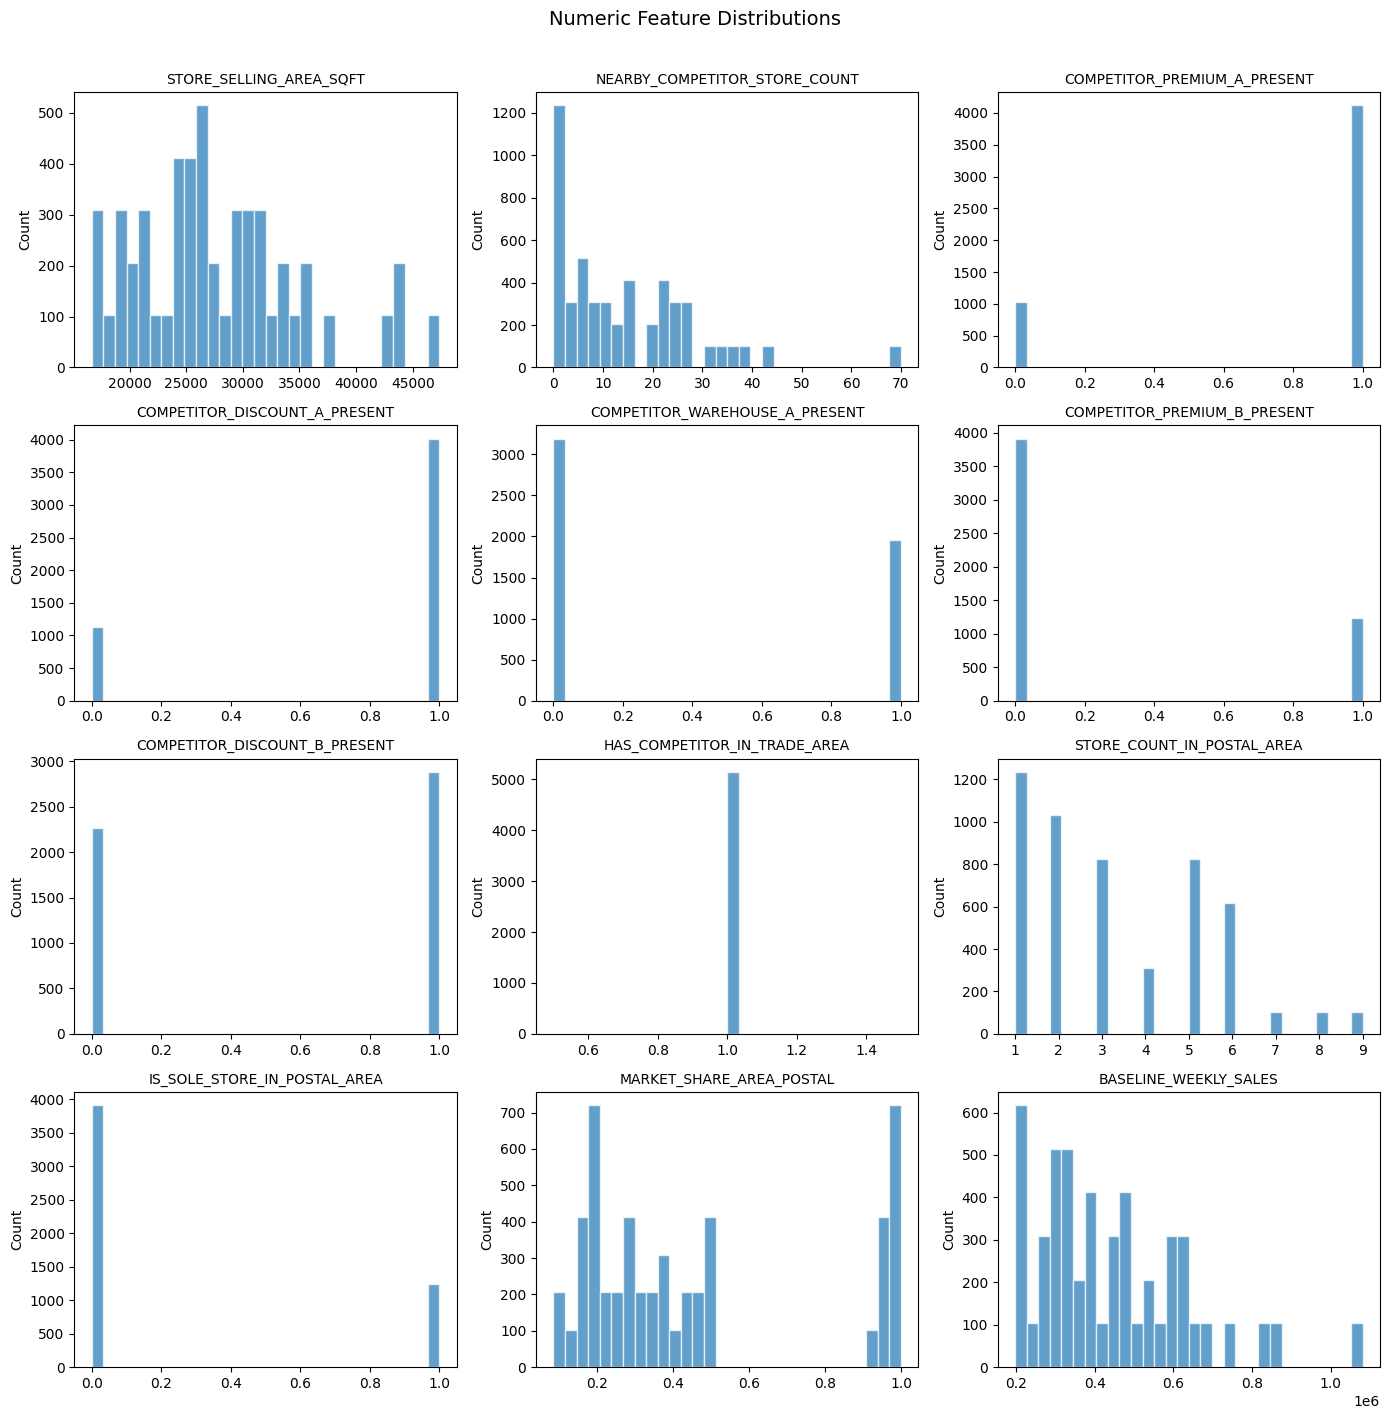

In [16]:
# Numeric feature histograms (exclude target and id)
plot_cols = [c for c in numeric_cols if c != y]
plot_cols = plot_cols[:12]  # Limit to 12 for readability

if plot_cols:
    ncols = 3
    nrows = (len(plot_cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        vals = df[col].dropna()
        axes[i].hist(vals, bins=30, edgecolor='white', alpha=0.7)
        axes[i].set_title(col, fontsize=10)
        axes[i].set_ylabel('Count')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features to plot (besides target).")

# 9. Feature analysis
Analyze feature names, based on the context provided. For example: if you are forecasting supermarket total net sales, then you can group features names like the following:
- STORE_SELLING_AREA_SQFT: store features
- IS_SOLE_STORE_IN_POSTAL_AREA and COMPETITOR_WAREHOUSE_A_PRESENT: competition features
- PRICE_INDEX_GROCERY_AMBIENT, PRICE_INDEX_SEAFOOD, PRICE_INDEX_FROZEN, PRICE_INDEX_GROCERY_AMBIENT, PRICE_INDEX_HEALTH_CARE: prices features
- UNIQUE_LOYALTY_CARDS, SALES_ON_LOYALTY_CARD, DISCOUNT_FLYER, SPEND_META, SPEND_TV: markerting features

While BASELINE_WEEKLY_SALES, TOTAL_TRANSACTIONS and TOTAL_GROSS_MARGIN are highly correlated to the target variable because represent the same phenomenon, therefore they should be removed to avoid collinearity issues. 

# ✅ CHECK POINT with the data scientist: ask if BASELINE_WEEKLY_SALES, TOTAL_TRANSACTIONS and TOTAL_GROSS_MARGIN should be removed because they are collinear of if the Data Scientist wants to perform a PCA on those features.

# 10. Summary

Key findings to carry into profiling and clustering (NB04-NB05):

In [17]:
n_stores = df[unique_id].nunique()
n_weeks = df[date_var].nunique()
total_obs = len(df)
na_pct = df[y].isna().sum() / total_obs * 100
zero_pct = (df[y] == 0).sum() / total_obs * 100
cv_range = f"{store_stats['cv'].min():.3f} - {store_stats['cv'].max():.3f}"
mean_range = f"{store_stats['mean'].min():,.0f} - {store_stats['mean'].max():,.0f}"

print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"Stores:              {n_stores}")
print(f"Weeks:               {n_weeks}")
print(f"Total observations:  {total_obs:,}")
print(f"Missing target (%%):  {na_pct:.1f}%")
print(f"Zero target (%%):     {zero_pct:.1f}%")
print(f"Mean sales range:    {mean_range}")
print(f"CV range:            {cv_range}")
print(f"Numeric features:    {len(numeric_cols)}")
print(f"Categorical features:{len(cat_cols)}")
print(f"Outlier stores:      {(outlier_df['n_outliers'] > 0).sum()} / {n_stores}")
print("=" * 60)

EDA SUMMARY
Stores:              50
Weeks:               103
Total observations:  5,150
Missing target (%%):  0.0%
Zero target (%%):     0.0%
Mean sales range:    281,719 - 1,167,576
CV range:            0.092 - 0.211
Numeric features:    91
Categorical features:2
Outlier stores:      49 / 50
